# Fraud Detection in Internship Applications

## Project Overview

Internship platforms may receive suspicious applications containing duplicate information, unusually rapid submissions, or inconsistent applicant data. These activities can affect data quality and reduce the fairness of the internship selection process.

This project analyzes internship application data to identify suspicious patterns using data analysis and machine learning techniques. The objective is to detect potentially fraudulent applications and generate alerts for further investigation.

## Project Objectives

- Detect duplicate application patterns.
- Identify rapid submission behavior.
- Analyze inconsistent application data.
- Apply Isolation Forest for anomaly detection.
- Apply K-Means Clustering to identify abnormal groups.
- Generate alerts for suspicious applications.

## Machine Learning Algorithms

- Isolation Forest
- K-Means Clustering

## Dataset Information

| Attribute | Value |
|-----------|-------|
| Dataset | Internship Applications Dataset |
| File Name | internship_applications_2025.csv |
| Year | 2025 |
| Total Records | 100,000 |
| Problem Type | Anomaly Detection |

## Dataset Overview

This project uses an internship application dataset containing **100,000 application records** collected throughout **2025**. The dataset includes applicant information, educational background, internship preferences, submission behavior, and fraud-related attributes used to analyze suspicious application patterns.

### Dataset Features

| Column | Description |
|---------|-------------|
| Application_ID | Unique application identifier. |
| Applicant_Name | Name of the applicant. |
| Email | Applicant's email address. |
| Gender | Gender of the applicant. |
| Age | Age of the applicant. |
| City | Applicant's city of residence. |
| Education | Highest educational qualification. |
| Institute | Educational institute. |
| Department | Internship department selected. |
| Internship_Track | Internship track selected by the applicant. |
| CGPA | Academic performance (CGPA). |
| Experience_Level | Previous experience level. |
| Application_Date | Date of application submission. |
| Application_Time | Time of application submission. |
| Submission_Gap_Seconds | Time gap between application submissions. |
| IP_Address | IP address used during submission. |
| Device_ID | Device identifier used during submission. |
| Browser | Browser used to submit the application. |
| Operating_System | Operating system used during submission. |
| Resume_Uploaded | Resume upload status. |
| Profile_Completion | Profile completion percentage. |
| Fraud_Reason | Reason associated with suspicious activity. |
| Application_Status | Final application status (Normal or Suspicious). |

## Import Required Libraries

The following libraries are imported to load, manipulate, and explore the internship application dataset.

In [16]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np


# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For Long Text Wrap
import textwrap

## Load Dataset

The internship application dataset is loaded into a Pandas DataFrame for analysis. The application date and time columns are converted into appropriate formats to support time-based analysis.

In [2]:
# ==========================================
# Load Dataset
# ==========================================

# Load Dataset
df = pd.read_csv(
    "../dataset/raw/internship_applications_2025.csv"
)

# Create a Copy of the Dataset
df_clean = df.copy()

## Dataset Overview

Before starting the fraud detection process, the dataset is examined to understand its overall structure and quality. This includes reviewing the dataset preview, dimensions, data types, missing values, and duplicate records to ensure the data is suitable for further analysis.

In [3]:
# ==========================================
# Dataset Overview
# ==========================================

# Display first five records
df.head().T

,0,1,2,3,4
Application_ID,APP000001,APP000002,APP000003,APP000004,APP000005
Applicant_Name,Kamran Nawaz,Fahad Ansari,Talha Gill,Bilal Gill,Zain Cheema
Email,kamran.nawaz1689@icloud.com,fahad.ansari1529@hotmail.com,talha.gill1664@hotmail.com,bilal.gill535@yahoo.com,zain.cheema2631@hotmail.com
Gender,Male,Male,Male,Male,Male
Age,20,23,21,19,26
City,Karachi,Karachi,Lahore,Lahore,Faisalabad
Education,BS Computer Science,BS Artificial Intelligence,BS Software Engineering,FSC (Pre-Engineering),BS Computer Science
Institute,University of Education,Virtual University of Pakistan,National University of Sciences and Technology,Government Post Graduate College,Virtual University of Pakistan
Department,App Development,Frontend Development,Backend Development,App Development,Graphic Design
Internship_Track,Flutter,React,PHP,Flutter,Photoshop


In [4]:
# ==========================================
# Dataset Shape
# ==========================================

print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 100,000
Number of Columns : 23


In [5]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Application_ID          100000 non-null  str    
 1   Applicant_Name          100000 non-null  str    
 2   Email                   100000 non-null  str    
 3   Gender                  100000 non-null  str    
 4   Age                     100000 non-null  int64  
 5   City                    100000 non-null  str    
 6   Education               100000 non-null  str    
 7   Institute               100000 non-null  str    
 8   Department              100000 non-null  str    
 9   Internship_Track        100000 non-null  str    
 10  CGPA                    100000 non-null  float64
 11  Experience_Level        100000 non-null  str    
 12  Application_Date        100000 non-null  str    
 13  Application_Time        100000 non-null  str    
 14  Submission_Gap_Seconds  100000 n

**Observation:**

- The dataset contains **100,000 records** and **23 columns**.
- Most columns have complete data with the correct data types.
- The **Fraud_Reason** column contains **19,651 non-null** values because it is only applicable to suspicious applications.
- The dataset includes **19 string**, **3 integer**, and **1 float** column, making it suitable for further preprocessing and analysis.

In [6]:
# ==========================================
# Missing Values
# ==========================================

missing_values = df.isnull().sum()

missing_values

Application_ID                0
Applicant_Name                0
Email                         0
Gender                        0
Age                           0
City                          0
Education                     0
Institute                     0
Department                    0
Internship_Track              0
CGPA                          0
Experience_Level              0
Application_Date              0
Application_Time              0
Submission_Gap_Seconds        0
IP_Address                    0
Device_ID                     0
Browser                       0
Operating_System              0
Resume_Uploaded               0
Profile_Completion            0
Fraud_Reason              80349
Application_Status            0
dtype: int64

In [7]:
# ==========================================
# Duplicate Records
# ==========================================

print(f"Duplicate Records : {df.duplicated().sum():,}")

Duplicate Records : 0


**Observation**

- The dataset contains **100,000 application records** and **23 features**.
- No fully duplicated records were found in the dataset.
- Missing values are present only in the **Fraud_Reason** column because normal applications do not have an associated fraud reason.
- The dataset is complete, well-structured, and ready for fraud pattern analysis.

## Handling Missing Values

Before proceeding with fraud pattern analysis, missing values are examined to determine the appropriate preprocessing strategy. The **Fraud_Reason** column contains missing values because it is only applicable to suspicious applications. Therefore, these missing values are replaced with **"None"** to ensure consistency during analysis and visualization.

In [8]:
# ==========================================
# Missing Values Before Preprocessing
# ==========================================

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Fraud_Reason    80349
dtype: int64

In [9]:
# ==========================================
# Fraud Reason Value Counts
# ==========================================

df["Fraud_Reason"].value_counts(dropna=False)

Fraud_Reason
NaN                                                                           80349
Duplicate Email                                                                3976
Duplicate IP                                                                   3396
Duplicate Device                                                               2690
Rapid Submission                                                               1084
Low Profile Completion                                                          890
Resume Missing                                                                  736
Duplicate Email, Rapid Submission                                               719
Duplicate IP, Rapid Submission                                                  627
Rapid Submission, Resume Missing, Low Profile Completion                        576
Duplicate Email, Low Profile Completion                                         550
Duplicate IP, Low Profile Completion                           

**Observation:**

- The **Fraud_Reason** column contains **80,349** missing values.
- These missing values represent **normal applications** that do not have any associated fraud reason.
- Since the missing values indicate the absence of suspicious activity rather than incomplete data, replacing them with **"None"** ensures consistent analysis and visualization.

In [10]:
# ==========================================
# Fill Missing Fraud Reasons
# ==========================================

df_clean["Fraud_Reason"] = df_clean["Fraud_Reason"].fillna("None")

In [11]:
# ==========================================
# Verify Missing Values
# ==========================================

print(f"Missing Values in Fraud_Reason : {df_clean['Fraud_Reason'].isnull().sum()}")

Missing Values in Fraud_Reason : 0


**Observation:**

- All missing values in the **Fraud_Reason** column have been successfully replaced with **"None"**.
- The column no longer contains null values, ensuring a complete and consistent dataset for fraud pattern analysis.
- The preprocessed dataset (**df_clean**) is now ready for further analysis and machine learning.

## Fraud Pattern Analysis

This section analyzes different application patterns to identify suspicious activities. The analysis helps understand common fraud patterns in the dataset before applying machine learning models.

### Application Status Distribution

This analysis shows the number of **Normal** and **Suspicious** applications in the dataset. It provides a quick overview of the application status before exploring different fraud patterns.

In [12]:
# ==========================================
# Application Status Distribution
# ==========================================

status_counts = (
    df_clean["Application_Status"]
    .value_counts()
)

status_counts

Application_Status
Normal        80349
Suspicious    19651
Name: count, dtype: int64

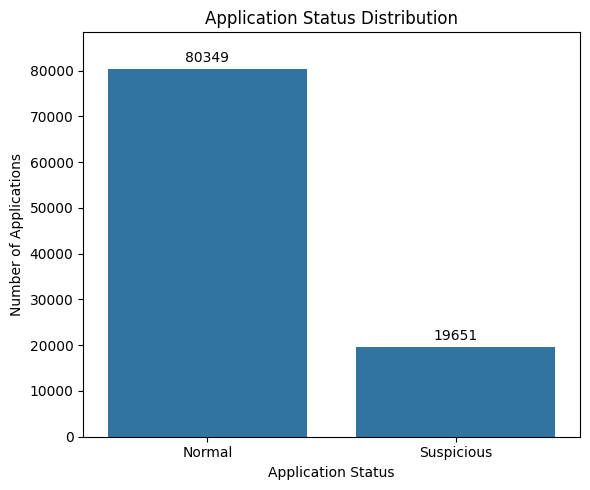

In [13]:
# ==========================================
# Application Status Distribution
# ==========================================

plt.figure(figsize=(6, 5))

ax = sns.countplot(
    data=df_clean,
    x="Application_Status"
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase Y-axis Limit
ax.set_ylim(0, status_counts.max() * 1.10)

plt.title("Application Status Distribution")
plt.xlabel("Application Status")
plt.ylabel("Number of Applications")

plt.tight_layout()

# Save Figure
plt.savefig(
    "../outputs/figures/01_application_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation:**

- The dataset contains **80,349 Normal** applications and **19,651 Suspicious** applications.
- Normal applications make up the majority of the dataset, while suspicious applications account for a smaller portion.
- The table and visualization show a clear difference between the two application categories, providing a good starting point for further fraud pattern analysis.

### Fraud Reason Distribution

This analysis shows the frequency of each fraud reason identified in suspicious applications. It helps understand the most common fraud patterns in the dataset.

In [14]:
# ==========================================
# Fraud Reason Distribution
# ==========================================

fraud_reason_counts = (
    df_clean["Fraud_Reason"]
    .value_counts()
)

fraud_reason_counts

Fraud_Reason
None                                                                          80349
Duplicate Email                                                                3976
Duplicate IP                                                                   3396
Duplicate Device                                                               2690
Rapid Submission                                                               1084
Low Profile Completion                                                          890
Resume Missing                                                                  736
Duplicate Email, Rapid Submission                                               719
Duplicate IP, Rapid Submission                                                  627
Rapid Submission, Resume Missing, Low Profile Completion                        576
Duplicate Email, Low Profile Completion                                         550
Duplicate IP, Low Profile Completion                           

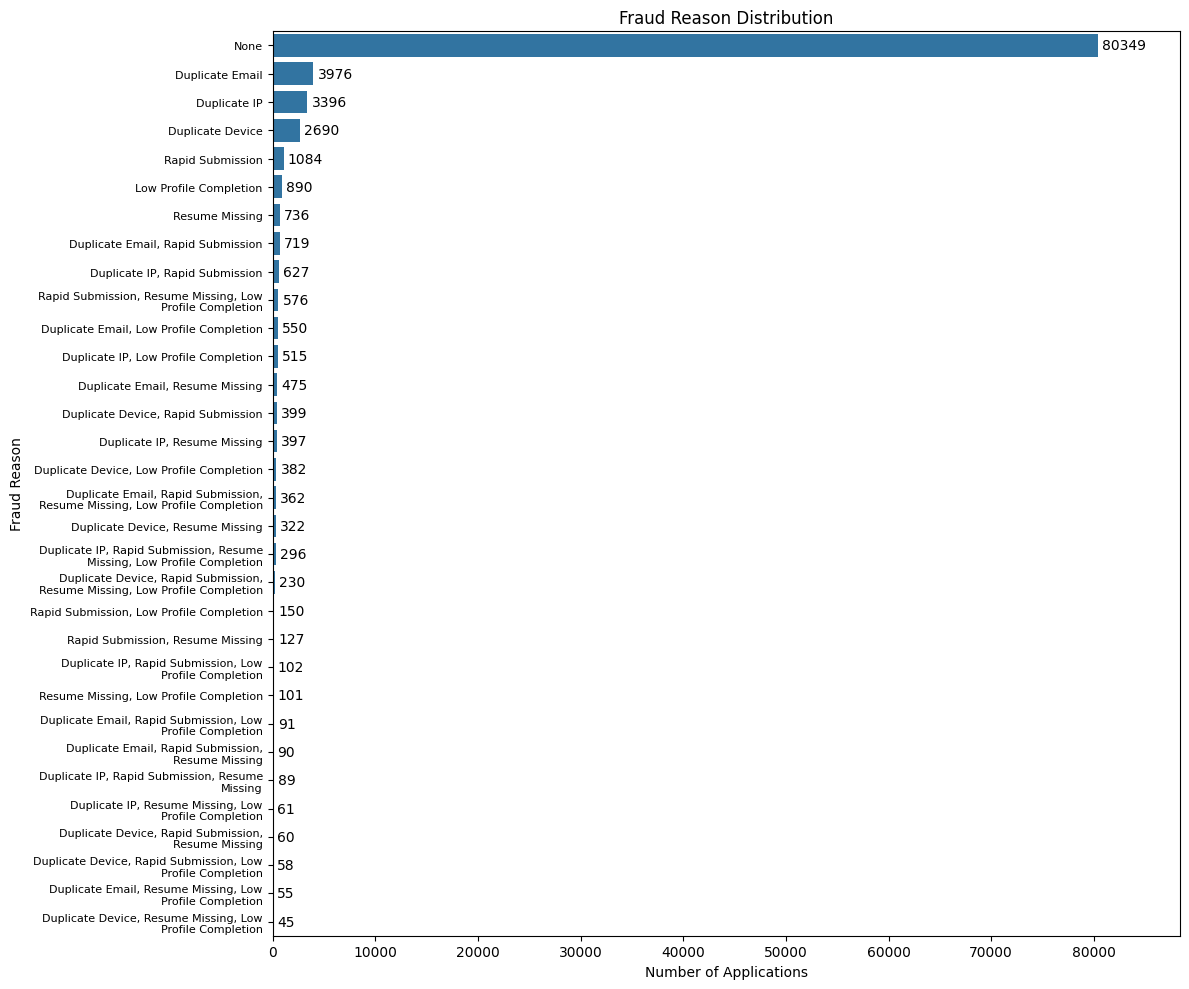

In [20]:
# ==========================================
# Fraud Reason Distribution
# ==========================================

plt.figure(figsize=(12, 10))

ax = sns.countplot(
    data=df_clean,
    y="Fraud_Reason",
    order=fraud_reason_counts.index
)

# Add Data Labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Increase X-axis Limit
ax.set_xlim(0, fraud_reason_counts.max() * 1.10)

# Wrap Long Labels
wrapped_labels = [
    "\n".join(textwrap.wrap(label.get_text(), width=40))
    for label in ax.get_yticklabels()
]

ax.set_yticks(range(len(wrapped_labels)))
ax.set_yticklabels(wrapped_labels, fontsize=8)

plt.title("Fraud Reason Distribution")
plt.xlabel("Number of Applications")
plt.ylabel("Fraud Reason")

plt.tight_layout()

# Save Figure
plt.savefig(
    "../outputs/figures/02_fraud_reason_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation:**

- The **"None"** category has the highest number of applications (**80,349**), indicating that most applications do not contain any fraud indicators.
- Among the suspicious applications, **Duplicate Email (3,976)** is the most common fraud reason, followed by **Duplicate IP (3,396)** and **Duplicate Device (2,690)**.
- Some applications contain multiple fraud indicators, resulting in combined fraud reasons with lower frequencies.
- The distribution shows that while most applications are normal, several distinct fraud patterns are present in the dataset.